 1️⃣ Cherchons a savoir :

✔ Quels profils sont les plus fréquents ?
✔ Le dataset est-il équilibré ?
✔ Y a-t-il un biais ?

2️⃣ Pseudo-code:
charger dataset
compter nombre de CV par catégorie
trier par fréquence
visualiser (bar chart)
interpréter


In [3]:
# Importation des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [4]:
sns.set_style("whitegrid")
# Charger les données à partir du fichier CSV
df = pd.read_csv("../data/raw/UpdatedResumeDataSet.csv")

In [5]:
# Afficher les premières lignes du DataFrame
print("shape:", df.shape)
print("\nColumns:", df.columns)
print("Aperçu des données:")
print(df.head())

shape: (962, 2)

Columns: Index(['Category', 'Resume'], dtype='str')
Aperçu des données:
       Category                                             Resume
0  Data Science  Skills * Programming Languages: Python (pandas...
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...
2  Data Science  Areas of Interest Deep Learning, Control Syste...
3  Data Science  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4  Data Science  Education Details \r\n MCA   YMCAUST,  Faridab...


In [6]:
# DISTRIBUTION DES CATÉGORIES
category_counts = df['Category'].value_counts()

print("\nDistribution des catégories:")
print(category_counts)


Distribution des catégories:
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Mechanical Engineer          40
Sales                        40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Health and fitness           30
Electrical Engineering       30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


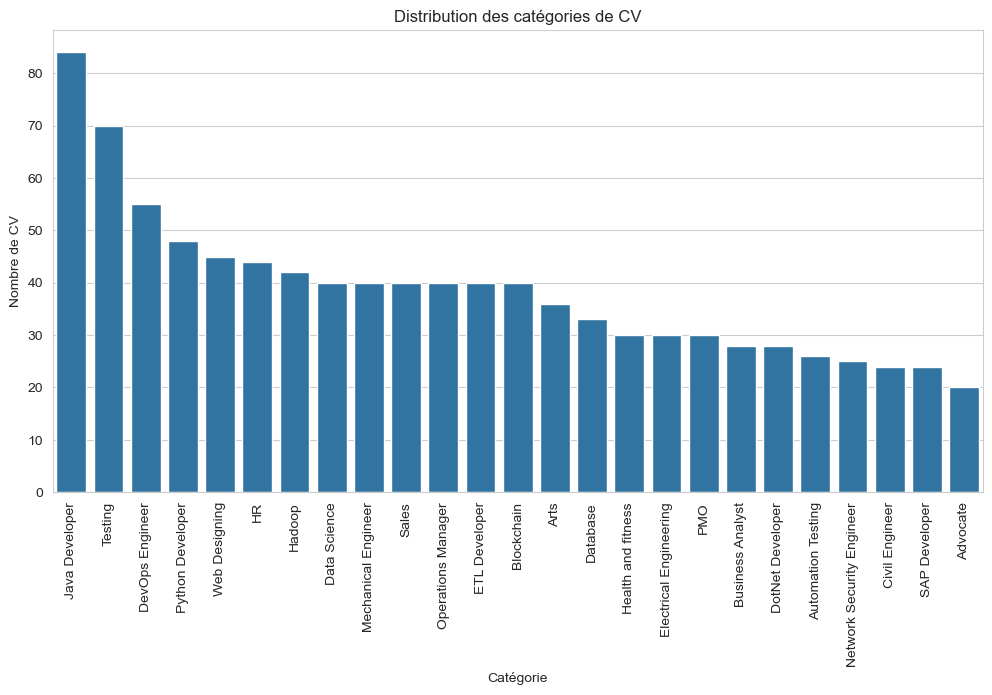

<Figure size 640x480 with 0 Axes>

In [7]:
# Visualisation de la distribution des catégories
plt.figure(figsize=(12, 6))

sns.barplot(
            x=category_counts.index, 
            y=category_counts.values
    )

plt.xticks(rotation=90)
plt.title("Distribution des catégories de CV")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de CV")
plt.show()

# Sauvegarde de la figure
plt.savefig("../outputs/category_counts.png")
category_counts.to_csv("../outputs/category_distribution.csv")


Statistiques de la longueur des CV:
count     962.000000
mean      450.497921
std       415.868459
min        19.000000
25%       166.000000
50%       329.000000
75%       589.250000
max      2209.000000
Name: resume_length, dtype: float64


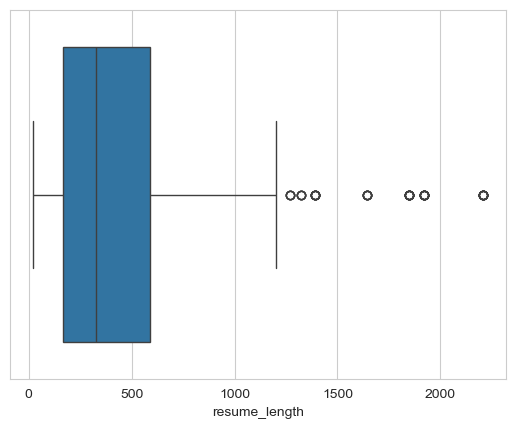

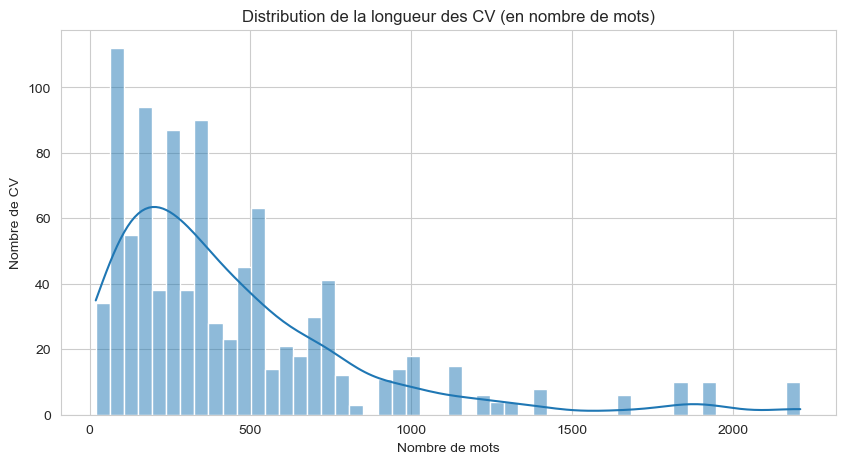

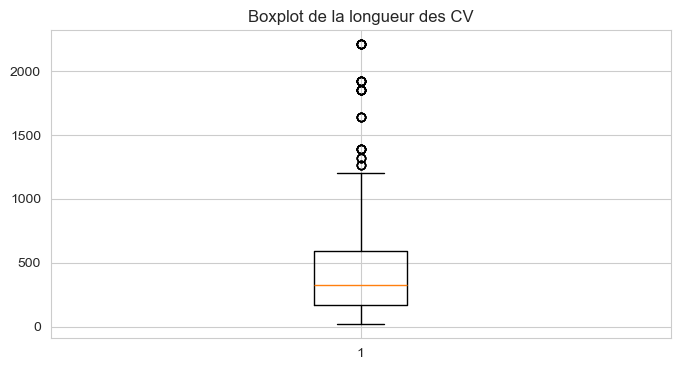

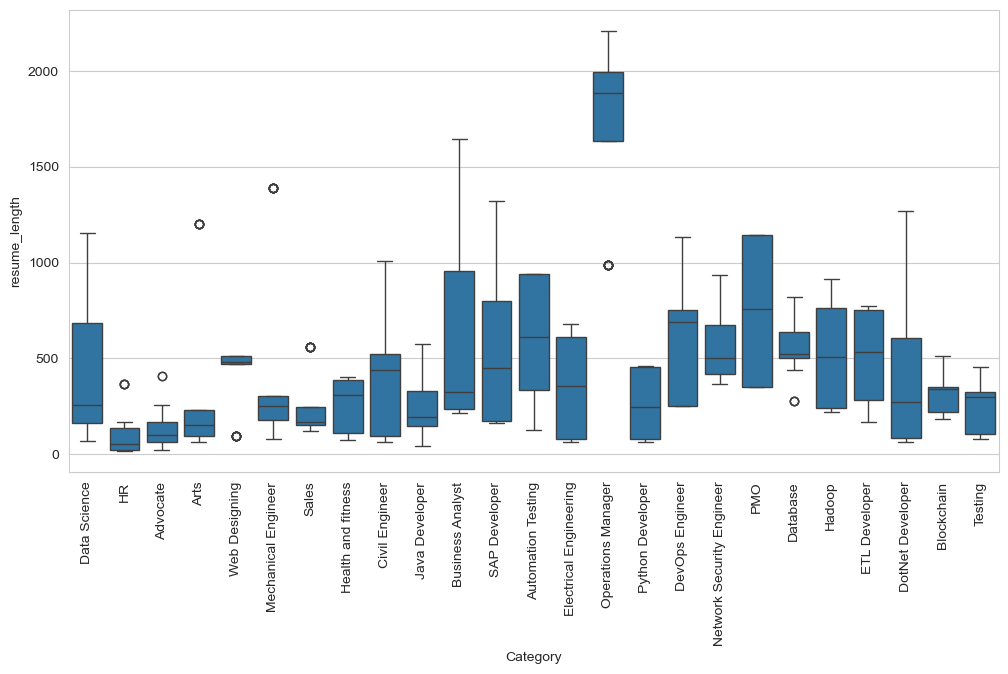

In [8]:
# ==============================
# LONGUEUR DES CV
# ==============================

# nombre de mots dans chaque CV
df['resume_length'] = df['Resume'].apply(lambda x: len(str(x).split()))

# stats globales
print("\nStatistiques de la longueur des CV:")
print(df['resume_length'].describe())
sns.boxplot(x=df['resume_length'])

#Histogramme de la longueur des CV
plt.figure(figsize=(10,5))
sns.histplot(df['resume_length'], bins=50, kde=True)

plt.title("Distribution de la longueur des CV (en nombre de mots)")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de CV")
plt.show()

# ==============================
# BOXPLOT
# ==============================

plt.figure(figsize=(8,4))
plt.boxplot(x=df['resume_length'])
plt.title("Boxplot de la longueur des CV")


# ==============================
# PAR CATÉGORIE 
# ==============================

plt.figure(figsize=(12,6))
sns.boxplot(x='Category', y='resume_length', data=df)
plt.xticks(rotation=90)

plt.show()

INTERPRETATION DEs Statistiques de la longueur des CV:
Problème 1 — CV courts
    ex:19 mots

Ce que cela peut entrainer:
 - modèle ne comprend rien
 - mauvaise classification

Problème 2 — CV longs
    ex : 2209 mots

Ce que cela peut entrainer:
    - bruit (informations inutiles)
    - modèle confus

Conclusion business:
Nous devons construire notre systeme de tel sorte qu'elle puisse:
    
    - filtrer
    - normaliser
    - nettoyer

Interprétation du Boxplot (resume_length):
1-Lecture visuelle du graphique
Ton boxplot montre :

    - boîte (Q1 → Q3) ≈ 150 → 600 mots
    - médiane ≈ 300 mots
    - moustache droite ≈ jusqu’à ~1200
    -  points isolés → au-delà de 1200 (jusqu’à 2200)

2-Analyse statistique profonde
     A. Distribution principale

     50% des CV sont entre :

     ~150 et ~600 mots

      C’est la zone normale
     B. Médiane

     ≈ 300 mots

     Cela signifie :

✔ la plupart des CV sont relativement courts
✔ la moyenne est gonflée par les longs CV

 C. Outliers 

     Tous les points à droite :

     > 1200 mots; Ce sont des outliers

 D. Asymétrie (skewness)

     Distribution vers la droite (right-skewed)

     Cela veut dire :

     beaucoup de CV courts
     quelques CV très longs

3-Interprétation BUSINESS
 Problème 1 — CV trop longs

 Exemple :

    1500 → 2200 mots

Impact :

- bruit énorme
- informations inutiles
- modèle perturbé

Problème 2 — incohérence des formats

    CV différents :

    PDF → texte brut
    Word → structuré
    copier-coller → bruit

 dataset réaliste mais sale

 Conclusion business
  Notre systeme dois:
  
    -standardiser les CV
    -gérer les extrêmes
    -améliorer la qualité du texte


 
     



In [9]:
import numpy as np
# 1. Calcul longueur des CV
df['resume_length'] = df['Resume'].apply(lambda x: len(str(x).split()))
# 2. Limitons et filtrons les CV trop courts ou trop longs pour enlever les outliers
df = df[(df['resume_length'] >50)&(df['resume_length'] < 1200)]

nterprétation de l’histogramme (resume_length)

On observe :
    ✔ une forte concentration à gauche
    ✔ une longue queue à droite
Donc distribution asymétrique à droite (right-skewed)

A. Zone principale
    une grande majorité des cv sont entre 100 et 400 mots

B. Diminution progressive
  Enttre 400 et 800 mots  le nombre de CV diminue 

C. Longue traîne
Entre 800 → 2200 mots très peu de CV mais existent

3- Problème clé détecté

 Notre dataset contient :

 CV très longs (bruit)

 exemples :

-descriptions inutiles
-répétitions
-mauvais format

CV très courts
peu d’information



Ce graphique nous dit : 
“Tous les CV n’ont pas la même valeur informationnelle”

Interprétation du boxplot par catégorie:
    Interprétation du boxplot par catégorie:

        A. Métiers avec CV très longs
            On a:Operations Manager,PMO , Business Analyst  ; car il           comportent :
                ex :

                    ✔ expériences multiples
                    ✔ descriptions longues
                    ✔ gestion / management

        B. Métiers avec forte variabilité
            On a :DevOps Engineer,ETL Developer,Hadoop
            Cette forte variabilité peut dù à des  CV très différents , ce qui est dificile à modéliser 

CONCLUSION:
Notre modèle peut traiter tois les cv de la meme façon mais les distributions sont différentes par métier, la longeur du cv dépend du métier.


In [10]:


# 3. Feature normalisée par catégorie  
df['length_normalized'] = df.groupby('Category')['resume_length'].transform(lambda x: (x - x.mean()) / x.std())

# 4. Log-transformer la longueur des CV pour réduire l'impact des outliers
df['log_length'] = np.log1p(df['resume_length'])

In [11]:
# Fonction clean_text
import re
def clean_text(text):
    text = text.lower()  # Convertir en minuscules
    text = re.sub(r'[^\w\s]', '', text)  # Supprimer la ponctuation
    text = re.sub(r'\d+', '', text)  # Supprimer les chiffres
    text = re.sub(r'\s+', ' ', text).strip()  # Supprimer les espaces supplémentaires
    return text

In [12]:
# appliquer la fonction de nettoyage à la colonne 'Resume'
df['clean_resume'] = df['Resume'].apply(clean_text)

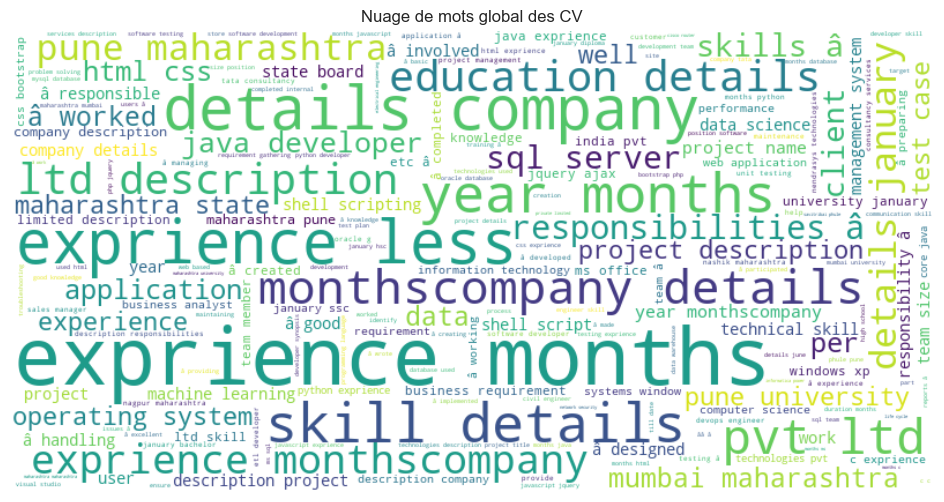

<Figure size 640x480 with 0 Axes>

In [14]:
 # WordCloud GLOBAL 
from wordcloud import WordCloud #  pour générer des nuages de mots
import matplotlib.pyplot as plt
# Générer un nuage de mots pour les CV
text = ' '.join(df['clean_resume'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear') # Afficher le nuage de mots
plt.axis('off')
plt.title("Nuage de mots global des CV")
plt.show() 
# Sauvegarde de la figure
plt.savefig("../outputs/wordcloud_global.png")



WordCloud PAR MÉTIER

ex:Data Science


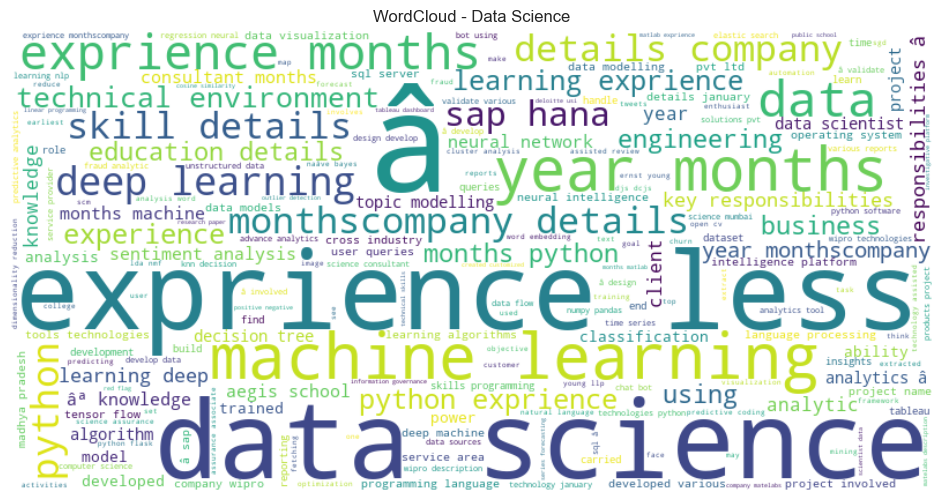

In [15]:
ds_text = " ".join(df[df['Category'] == 'Data Science']['clean_resume'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ds_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Data Science")
plt.show()

ex : Java Developer

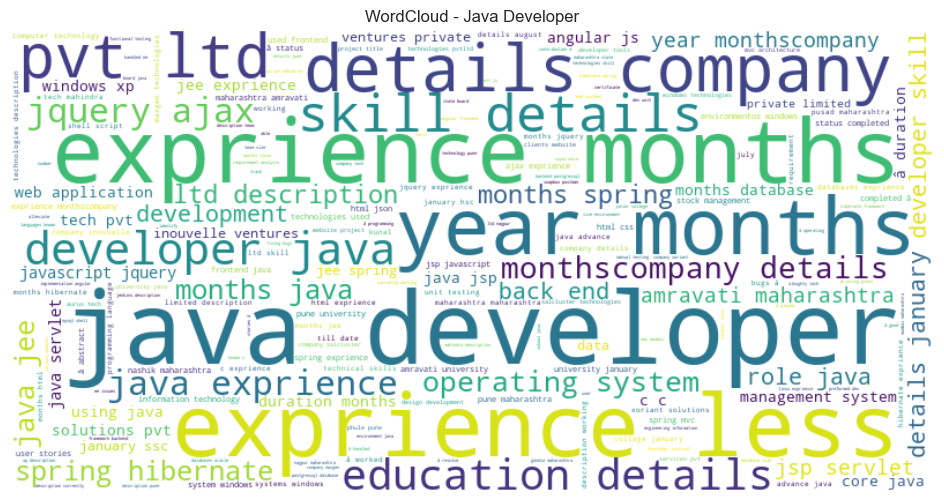

In [16]:
Java_text = " ".join(df[df['Category'] == 'Java Developer']['clean_resume'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(Java_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Java Developer")
plt.show()

On voit bo=ien tous les mots clé dans la categori "Java Developer" dont notre model va plus s'en servir souvent pour apprendre

Implémentation TF-IDF

TF-IDF = importance d’un mot dans un document

In [26]:
df = df.reset_index(drop=True)
from sklearn.feature_extraction.text import TfidfVectorizer
# Vectorizer les CV en utilisant TF-IDF
tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words='english'
)

# Appliquer le TF-IDF sur les CV nettoyés
X = tfidf.fit_transform(df['clean_resume'])

#  Voir les mots les plus importants 
feature_names = tfidf.get_feature_names_out()
# Afficher les 20 mots les plus importants
print("Top 20 mots les plus importants:")
print(feature_names[:20])

Top 20 mots les plus importants:
['aaa' 'ab' 'abacus' 'abad' 'abap' 'abilities' 'ability' 'able' 'abstract'
 'academic' 'academy' 'acb' 'accenture' 'accept' 'acceptance' 'accepted'
 'accepting' 'access' 'accessories' 'accolite']


Extraction des mots importants

In [27]:
import numpy as np
def get_top_words_per_category(df,X,feature_names, category, top_n=20):
    # Filtrer les CV de la catégorie spécifiée
    category_indices = df[df['Category'] == category].index
    category_X = X[category_indices]
    
    # Calculer la moyenne des scores TF-IDF pour chaque mot dans cette catégorie
    mean_tfidf = np.asarray(category_X.mean(axis=0)).flatten()
    
    # Obtenir les indices des mots les plus importants
    top_indices = mean_tfidf.argsort()[-top_n:][::-1]
    # Obtenir les mots correspondants à ces indices
    top_words = [feature_names[i] for i in top_indices]
    
    # Afficher les mots les plus importants pour cette catégorie
    print(f"Top {top_n} mots pour la catégorie '{category}':")
    for word, score in zip(top_words,mean_tfidf[top_indices]):
        print(f"{word}: { score:.4f}")

    return top_words

In [28]:
# Exemple d'utilisation 
print("Data Science:", get_top_words_per_category(df, X, feature_names, "Data Science"))
print("Java Developer:", get_top_words_per_category(df, X, feature_names, "Java Developer"))
print("HR:", get_top_words_per_category(df, X, feature_names, "HR"))


Top 20 mots pour la catégorie 'Data Science':
data: 0.2108
year: 0.1721
learning: 0.1453
python: 0.1452
exprience: 0.1416
months: 0.1347
science: 0.1313
machine: 0.1208
analytics: 0.0736
âª: 0.0603
details: 0.0583
analysis: 0.0579
deep: 0.0575
tableau: 0.0491
visualization: 0.0476
matlab: 0.0472
matelabs: 0.0457
business: 0.0446
algorithms: 0.0422
using: 0.0411
Data Science: ['data', 'year', 'learning', 'python', 'exprience', 'months', 'science', 'machine', 'analytics', 'âª', 'details', 'analysis', 'deep', 'tableau', 'visualization', 'matlab', 'matelabs', 'business', 'algorithms', 'using']
Top 20 mots pour la catégorie 'Java Developer':
java: 0.2855
developer: 0.1319
exprience: 0.1130
months: 0.1075
ajax: 0.0956
jsp: 0.0919
spring: 0.0918
jee: 0.0818
hibernate: 0.0781
year: 0.0739
servlet: 0.0712
technologies: 0.0627
details: 0.0612
amravati: 0.0543
json: 0.0514
maharashtra: 0.0496
jquery: 0.0494
javascript: 0.0490
mysql: 0.0490
pvt: 0.0470
Java Developer: ['java', 'developer', 'exprie

In [29]:
# Sauvegarder pour Power BI
results = []
categories = df['Category'].unique()
for category in categories:
    top_words = get_top_words_per_category(df, X, feature_names, category)
    
    for word in top_words:
        results.append({
            "Category": category,
            "Word": word
        })

skill_df = pd.DataFrame(results)
skill_df.to_csv("../outputs/top_words_per_category.csv", index=False)

Top 20 mots pour la catégorie 'Data Science':
data: 0.2108
year: 0.1721
learning: 0.1453
python: 0.1452
exprience: 0.1416
months: 0.1347
science: 0.1313
machine: 0.1208
analytics: 0.0736
âª: 0.0603
details: 0.0583
analysis: 0.0579
deep: 0.0575
tableau: 0.0491
visualization: 0.0476
matlab: 0.0472
matelabs: 0.0457
business: 0.0446
algorithms: 0.0422
using: 0.0411
Top 20 mots pour la catégorie 'HR':
hr: 0.2073
dbms: 0.1090
mba: 0.0994
dynamics: 0.0979
details: 0.0934
exprience: 0.0919
kerala: 0.0875
accounting: 0.0756
management: 0.0710
finance: 0.0698
ax: 0.0695
months: 0.0674
payroll: 0.0631
school: 0.0612
engineering: 0.0611
computer: 0.0597
january: 0.0570
skills: 0.0568
statutory: 0.0544
june: 0.0543
Top 20 mots pour la catégorie 'Advocate':
law: 0.2778
legal: 0.2375
advocate: 0.1751
court: 0.1662
llb: 0.0961
courts: 0.0794
district: 0.0785
criminal: 0.0783
matters: 0.0767
chennai: 0.0733
solapur: 0.0728
drafting: 0.0699
details: 0.0691
university: 0.0669
january: 0.0609
tax: 0.0574


On va mnt entrainer plusieurs modèles sur nos données et voie celui qui donne le meilleur résultat. En gros , on va prédire , c'est dire : 
De CV à  Category (Data Science, Java Developer, HR, etc.)


In [31]:
#  Préparer les données
from sklearn.model_selection import train_test_split

# feartures et labels
X_data = X
y = df['Category']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size=0.2, random_state=42, stratify=y)

Modèle 1 — Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
# Modèle 1 — Logistic Regression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

#Évaluation du modèle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred_lr = model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Précision du modèle Logistic Regression : {accuracy_lr}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_lr))
#print("\nMatrice de confusion :")
#print(confusion_matrix(y_test, y_pred_lr))


Précision du modèle Logistic Regression : 0.9828571428571429

Rapport de classification :
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         3
                     Arts       1.00      1.00      1.00         6
       Automation Testing       1.00      0.60      0.75         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         4
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       0.75      1.00      0.86         6
                       HR       1.00  

Modèle 2 — Random Forest


In [34]:
from sklearn.ensemble import RandomForestClassifier
# Modèle 2 — Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf = model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Précision du modèle Random Forest : {accuracy_rf}")

Précision du modèle Random Forest : 0.9771428571428571


Modèle 3 — Naive Bayes

In [35]:
from sklearn.naive_bayes import MultinomialNB
# Modèle 3 — Naive Bayes
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Précision du modèle Naive Bayes : {accuracy_nb}")

Précision du modèle Naive Bayes : 0.9142857142857143


On constate que notre meilleur model est "LogisticRegression"

In [36]:
best_model = model_lr

Sauvegarder le modèle

In [37]:
import joblib
joblib.dump(best_model, "../models/resume_classifier.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

Tester une prédiction réelle

In [38]:
sample_cv = ["Experienced in Python, machine learning, data analysis"]
sample_cv = tfidf.transform(sample_cv)
prediction = best_model.predict(sample_cv)
print(f"Catégorie prédite pour le CV d'exemple : {prediction[0]}")

Catégorie prédite pour le CV d'exemple : Data Science


Optimisation de notre model avec le gridsearch

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

# grid search pour trouver les meilleurs hyperparamètres
param_grid = {
    'C': [0.01, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid = GridSearchCV(
    model, 
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
# Entraîner le modèle avec les meilleurs hyperparamètres trouvés
grid.fit(X_train, y_train)

d:\anaconda\envs\cv_matching\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


Afficher meilleur modèle avec ses hyperparamètres

In [41]:
print("Meilleurs hyperparamètres :", grid.best_params_)
print(f"Meilleur cv score : {grid.best_score_:.4f}")

Meilleurs hyperparamètres : {'C': 10, 'solver': 'liblinear'}
Meilleur cv score : 0.9893


Prédictions

In [42]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
from sklearn.metrics import classification_report
print("\nRapport de classification du meilleur modèle :")
print(classification_report(y_test, y_pred))


Rapport de classification du meilleur modèle :
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         3
                     Arts       1.00      1.00      1.00         6
       Automation Testing       1.00      0.60      0.75         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         4
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      1.00      1.00        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       0.75      1.00      0.86         6
                       HR       1.00      1.00      1.00         5
             

système de matching + ranking

IMPLÉMENTATION
Étape 1 — Job Description

In [43]:
job_description = "Looking for a data scientist with experience in Python, machine learning, and data analysis, deep learning, and SQL."

Étape 2 — Vectoriser

In [44]:
job_vec = tfidf.transform([job_description])
cv_vecs = tfidf.transform(df['clean_resume'])

Étape 3 — Calculer similarité

In [45]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_scores = cosine_similarity(job_vec, cv_vecs)
similarity_scores = similarity_scores.flatten()

Étape 4 —Ajouter score au dataset

In [46]:
df['match_score'] = similarity_scores

Étape 5 — Ranking

In [48]:
ranked_df = df.sort_values(by='match_score', ascending=False)

Étape 6 — Voir top candidats

In [49]:
top_candidates = ranked_df[['Resume', 'Category', 'match_score']].head(10)
print("\nTop 10 candidats les plus pertinents pour la description de poste :")
print(top_candidates)


Top 10 candidats les plus pertinents pour la description de poste :
                                               Resume      Category  \
28  Personal Skills â¢ Ability to quickly grasp t...  Data Science   
18  Personal Skills â¢ Ability to quickly grasp t...  Data Science   
38  Personal Skills â¢ Ability to quickly grasp t...  Data Science   
8   Personal Skills â¢ Ability to quickly grasp t...  Data Science   
6   Skills â¢ Python â¢ Tableau â¢ Data Visuali...  Data Science   
26  Skills â¢ Python â¢ Tableau â¢ Data Visuali...  Data Science   
16  Skills â¢ Python â¢ Tableau â¢ Data Visuali...  Data Science   
36  Skills â¢ Python â¢ Tableau â¢ Data Visuali...  Data Science   
7   Education Details \r\n B.Tech   Rayat and Bahr...  Data Science   
27  Education Details \r\n B.Tech   Rayat and Bahr...  Data Science   

    match_score  
28     0.439460  
18     0.439460  
38     0.439460  
8      0.439460  
6      0.399081  
26     0.399081  
16     0.399081  
36   

Notre systeme fait ainsi : 

✔ shortlist automatique
✔ tri intelligent
✔ gain de temps RH

PROBLÈME ACTUEL:
Les limites de notre model actuel:

 ne comprend pas l’importance des skills
 traite tous les mots pareil
 pas de logique métier


Nous allons donc contruire un SMART RANKING qui va permettre un Score final = Similarité + Bonus skills + Bonus catégorie

ÉTAPE 1 — définir les SKILLS IMPORTANTES

In [ ]:
# ex de skills à rechercher dans les CV de data science 
important_skills = [
    "python",
    "machine learning",
    "deep learning",
    "sql",
    "data analysis",
    "pandas",
    "numpy",
    "tableau"
]

ÉTAPE 2 — fonction bonus skills

In [51]:
def skill_score(text, skills):
    text = text.lower()
    score = 0
    
    for skill in skills:
        if skill in text:
            score += 1
    
    return score / len(skills)  # normalisation

ÉTAPE 3 — bonus catégorie

In [52]:
def category_bonus(predicted_category, target_category):
    return 1 if predicted_category == target_category else 0

ÉTAPE 4 — SCORE FINAL

In [53]:
final_scores = []

target_category = "Data Science"

for i, row in df.iterrows():
    
    # Similarité TF-IDF
    sim_score = row['match_score']
    
    # Skill score
    skill_bonus = skill_score(row['Resume'], important_skills)
    
    # Catégorie bonus
    cat_bonus = category_bonus(row['Category'], target_category)
    
    # Score final (pondération)
    final_score = (
        0.6 * sim_score +
        0.3 * skill_bonus +
        0.1 * cat_bonus
    )
    
    final_scores.append(final_score)

df['final_score'] = final_scores

7️ RANKING FINAL

In [54]:
ranked_df = df.sort_values(by='final_score', ascending=False)

top_candidates = ranked_df[['Category', 'final_score']].head(10)

print(top_candidates)

        Category  final_score
28  Data Science     0.588676
38  Data Science     0.588676
18  Data Science     0.588676
8   Data Science     0.588676
17  Data Science     0.538048
27  Data Science     0.538048
7   Data Science     0.538048
37  Data Science     0.538048
20  Data Science     0.462803
0   Data Science     0.462803
